#**Василенко Иван ИБ N4170**

#**Методы оптимизации**

#**Лабораторная работа 2 Многокритериальная оптимизация**

###**Условия**

**Задача оптимизации рациона спортсмена. Идеальный рацион - максимально белковый с минимумом калорий и как можно дешевле.**

Переменные(неотрицательные):
- $x_1$ — количество граммов куриной грудки
- $x_2$ — граммов лосося
- $x_3$ — граммов овсянки
- $x_4$ — граммов брокколи
- $x_5$ — граммов бананов
- $x_6$ — граммов миндаля

Коэффициенты для целевых функций:

- Грамм белка на 100 грамм продукта: курица — 25, лосось — 20, овсянка — 13, брокколи — 3, бананы — 1, миндаль — 21.
- Калории на 100 грамм продукта: курица — 165, лосось — 208, овсянка — 389, брокколи — 34, бананы — 89, миндаль — 579.
- Стоимость за 100 грамм продукта: курица — 20, лосось — 50, овсянка — 5, брокколи — 10, бананы — 7, миндаль — 30.

Ограничения:

- Общий вес рациона не более 2000 г: $x_1 + x_2 + x_3 + x_4 + x_5 + x_6 \leq 2000$.
- Минимум 150 г белка в день: $0.25x_1 + 0.20x_2 + 0.13x_3 + 0.03x_4 + 0.01x_5 + 0.21x_6 \geq 150$.
- Максимум 2500 ккал: $1.65x_1 + 2.08x_2 + 3.89x_3 + 0.34x_4 + 0.89x_5 + 5.79x_6 \leq 2500$.
- Минимум 300 г углеводов (коэффициенты: курица — 0, лосось — 0, овсянка — 0.66, брокколи — 0.07, бананы — 0.23, миндаль — 0.22): $0x_1 + 0x_2 + 0.66x_3 + 0.07x_4 + 0.23x_5 + 0.22x_6 \geq 300$.
- Минимум 50 г жиров (коэффициенты: курица — 0.03, лосось — 0.13, овсянка — 0.07, брокколи — 0, бананы — 0, миндаль — 0.49): $0.03x_1 + 0.13x_2 + 0.07x_3 + 0x_4 + 0x_5 + 0.49x_6 \geq 50$.

**Математическая модель**

Целевые функции:

* $f_1(x) = 0.25x_1 + 0.20x_2 + 0.13x_3 + 0.03x_4 + 0.01x_5 + 0.21x_6$ → max (белок, г).
* $f_2(x) = 1.65x_1 + 2.08x_2 + 3.89x_3 + 0.34x_4 + 0.89x_5 + 5.79x_6$ → min (калории, ккал).
* $f_3(x) = 0.20x_1 + 0.50x_2 + 0.05x_3 + 0.10x_4 + 0.07x_5 + 0.30x_6$ → min (стоимость, руб).

Ограничения:

* $x_1 + x_2 + x_3 + x_4 + x_5 + x_6 \leq 2000$
* $0.25x_1 + 0.20x_2 + 0.13x_3 + 0.03x_4 + 0.01x_5 + 0.21x_6 \geq 150$
* $1.65x_1 + 2.08x_2 + 3.89x_3 + 0.34x_4 + 0.89x_5 + 5.79x_6 \leq 2500$
* $0.66x_3 + 0.07x_4 + 0.23x_5 + 0.22x_6 \geq 300$
* $0.03x_1 + 0.13x_2 + 0.07x_3 + 0.49x_6 \geq 50$
* $x_i \geq 0$ для всех i.

###**Решение методом последовательных уступок**

Метод последовательных уступок предполагает сортировку критериев по приоритету и последовательную оптимизацию с фиксированными уступками от предыдущих оптимумов.

Теоретическое обоснование сортировки функций: В многокритериальной оптимизации критерии сортируются по убыванию важности (приоритету), определяемому субъективно или экспертно. Теоретически это основано на лексикографическом порядке: сначала оптимизируется наиболее важный критерий до его идеала, затем следующий с допустимым отклонением (уступкой) от предыдущего, чтобы избежать доминирования менее важных критериев. Это обеспечивает Парето-оптимальность в смысле приоритетов, минимизируя потери по ключевым целям. Здесь приоритет:
1. белок (max, ключевой для спортсмена)
2. калории (min, для контроля)
3. стоимость (min, вторичный).

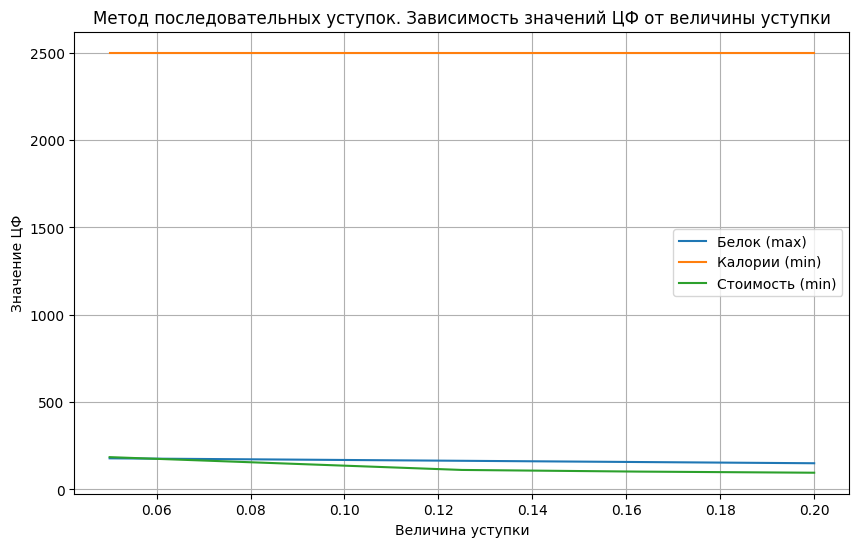

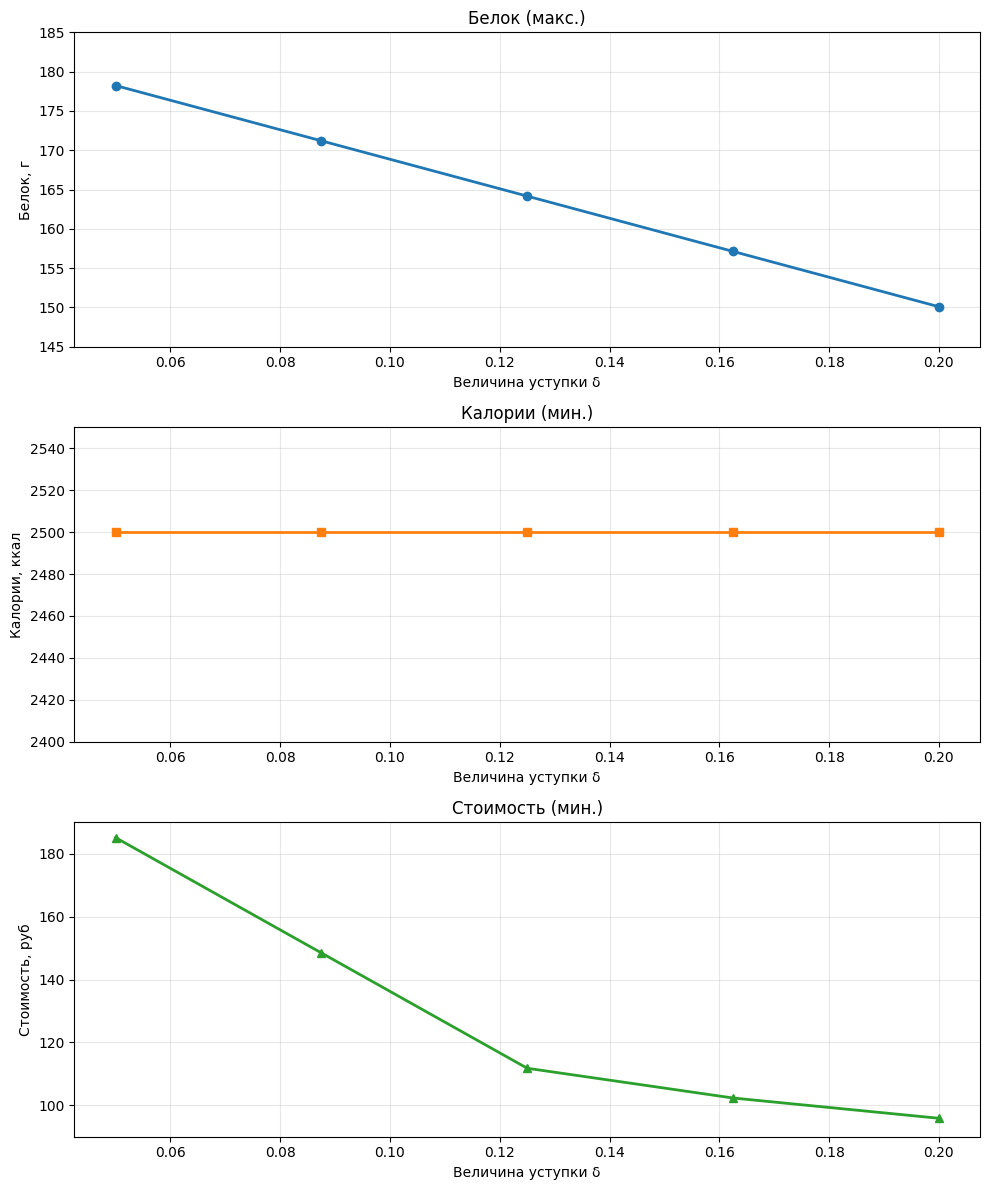

In [ ]:
!pip install pulp
import pulp
import matplotlib.pyplot as plt
import numpy as np

# Коэффициенты
prot_coeffs = [0.25, 0.20, 0.13, 0.03, 0.01, 0.21]
cal_coeffs = [1.65, 2.08, 3.89, 0.34, 0.89, 5.79]
cost_coeffs = [0.20, 0.50, 0.05, 0.10, 0.07, 0.30]
carb_coeffs = [0, 0, 0.66, 0.07, 0.23, 0.22]
fat_coeffs = [0.03, 0.13, 0.07, 0, 0, 0.49]

def solve_concessions(delta_perc):
    x = [pulp.LpVariable(f'x{i+1}', lowBound=0) for i in range(6)]

    # Шаг 1: Max белок
    prob1 = pulp.LpProblem("Max_Protein", pulp.LpMaximize)
    prob1 += pulp.lpSum(prot_coeffs[i] * x[i] for i in range(6))
    # Ограничения
    prob1 += pulp.lpSum(x) <= 2000
    prob1 += pulp.lpSum(prot_coeffs[i] * x[i] for i in range(6)) >= 150
    prob1 += pulp.lpSum(cal_coeffs[i] * x[i] for i in range(6)) <= 2500
    prob1 += pulp.lpSum(carb_coeffs[i] * x[i] for i in range(6)) >= 300
    prob1 += pulp.lpSum(fat_coeffs[i] * x[i] for i in range(6)) >= 50
    prob1.solve(pulp.PULP_CBC_CMD(msg=0))
    if pulp.LpStatus[prob1.status] != 'Optimal':
        return None, None, None
    max_prot = pulp.value(prob1.objective)

    # Шаг 2: Min калории с уступкой от max_prot
    delta1 = delta_perc * max_prot
    prob2 = pulp.LpProblem("Min_Calories", pulp.LpMinimize)
    prob2 += pulp.lpSum(cal_coeffs[i] * x[i] for i in range(6))
    prob2 += pulp.lpSum(prot_coeffs[i] * x[i] for i in range(6)) >= max_prot - delta1
    prob2 += pulp.lpSum(x) <= 2000
    prob2 += pulp.lpSum(prot_coeffs[i] * x[i] for i in range(6)) >= 150
    prob2 += pulp.lpSum(cal_coeffs[i] * x[i] for i in range(6)) <= 2500
    prob2 += pulp.lpSum(carb_coeffs[i] * x[i] for i in range(6)) >= 300
    prob2 += pulp.lpSum(fat_coeffs[i] * x[i] for i in range(6)) >= 50
    prob2.solve(pulp.PULP_CBC_CMD(msg=0))
    if pulp.LpStatus[prob2.status] != 'Optimal':
        return None, None, None
    min_cal = pulp.value(prob2.objective)

    # Шаг 3: Min стоимость с уступками от предыдущих
    delta2 = delta_perc * min_cal
    prob3 = pulp.LpProblem("Min_Cost", pulp.LpMinimize)
    prob3 += pulp.lpSum(cost_coeffs[i] * x[i] for i in range(6))
    prob3 += pulp.lpSum(prot_coeffs[i] * x[i] for i in range(6)) >= max_prot - delta1
    prob3 += pulp.lpSum(cal_coeffs[i] * x[i] for i in range(6)) <= min_cal + delta2
    prob3 += pulp.lpSum(x) <= 2000
    prob3 += pulp.lpSum(prot_coeffs[i] * x[i] for i in range(6)) >= 150
    prob3 += pulp.lpSum(cal_coeffs[i] * x[i] for i in range(6)) <= 2500
    prob3 += pulp.lpSum(carb_coeffs[i] * x[i] for i in range(6)) >= 300
    prob3 += pulp.lpSum(fat_coeffs[i] * x[i] for i in range(6)) >= 50
    prob3.solve(pulp.PULP_CBC_CMD(msg=0))
    if pulp.LpStatus[prob3.status] != 'Optimal':
        return None, None, None

    # Итоговые значения целевых функций
    final_prot = sum(prot_coeffs[i] * pulp.value(x[i]) for i in range(6))
    final_cal = sum(cal_coeffs[i] * pulp.value(x[i]) for i in range(6))
    final_cost = pulp.value(prob3.objective)
    return final_prot, final_cal, final_cost

# Тестирование
#Уступки
deltas = np.linspace(0.05, 0.20, 5)
results = [solve_concessions(d) for d in deltas]
results = [r for r in results if r[0] is not None]

prots = [r[0] for r in results]
cals = [r[1] for r in results]
costs = [r[2] for r in results]

# График всех 3 функций
plt.figure(figsize=(10, 6))
plt.plot(deltas[:len(prots)], prots, label='Белок (max)')
plt.plot(deltas[:len(cals)], cals, label='Калории (min)')
plt.plot(deltas[:len(costs)], costs, label='Стоимость (min)')
plt.xlabel('Величина уступки')
plt.ylabel('Значение ЦФ')
plt.title('Метод последовательных уступок. Зависимость значений ЦФ от величины уступки')
plt.legend()
plt.grid(True)
plt.show()

fig, axs = plt.subplots(3, 1, figsize=(10, 12))

# Белок
axs[0].plot(deltas[:len(prots)], prots, 'o-', color='tab:blue', linewidth=2, markersize=6)
axs[0].set_title('Белок (макс.)')
axs[0].set_xlabel('Величина уступки δ')
axs[0].set_ylabel('Белок, г')
axs[0].grid(True, alpha=0.3)
axs[0].set_ylim(145, 185)

# Калории
axs[1].plot(deltas[:len(cals)], cals, 's-', color='tab:orange', linewidth=2, markersize=6)
axs[1].set_title('Калории (мин.)')
axs[1].set_xlabel('Величина уступки δ')
axs[1].set_ylabel('Калории, ккал')
axs[1].grid(True, alpha=0.3)
axs[1].set_ylim(2400, 2550)

# Стоимость
axs[2].plot(deltas[:len(costs)], costs, '^-', color='tab:green', linewidth=2, markersize=6)
axs[2].set_title('Стоимость (мин.)')
axs[2].set_xlabel('Величина уступки δ')
axs[2].set_ylabel('Стоимость, руб')
axs[2].grid(True, alpha=0.3)
axs[2].set_ylim(90, 190)

plt.tight_layout()
plt.show()

График иллюстрирует следующее:
1) Даже при самой маленькой уступке минимизация калорий сразу «упирается» в верхнее ограничение 2500 ккал и дальше не может улучшиться.
2) По мере роста δ белок немного жертвуется, чтобы дать возможность улучшить следующий по приоритету критерий — стоимость.
3) Стоимость реально улучшается при увеличении уступки за счет сокращения белка.

###**Решение методом весовых коэффициентов**
Метод весовых коэффициентов (weighted sum) сводит задачу к скалярной. Вместо работы с тремя отдельными функциями формируется скалярная функция: $F(x) = -w_1 * f_1(x)^* + w_2 * f_2(x)^* + w_3 * f_3(x)^*$ → min ($f_1(x)^*$ максимизируется поэтому коэффициента $w_1$ отрицательный чтобы решать через pulp). Весовые коэффициенты подбирются имперически. Функции со звездочками это изначальные функции но нормализованные(их значения лежат на отрезке [0,1]). Чтобы получить нормализованные версии нужно найти предельные значения функций, куда они стремятся при заданых условиях, после чего поделить функции на соответствующие им предельные значения.

Максимальный белок = 187.61268900000002
Минимальные калории = 2265.2775271
Минимальная стоимость = 95.78386219999999


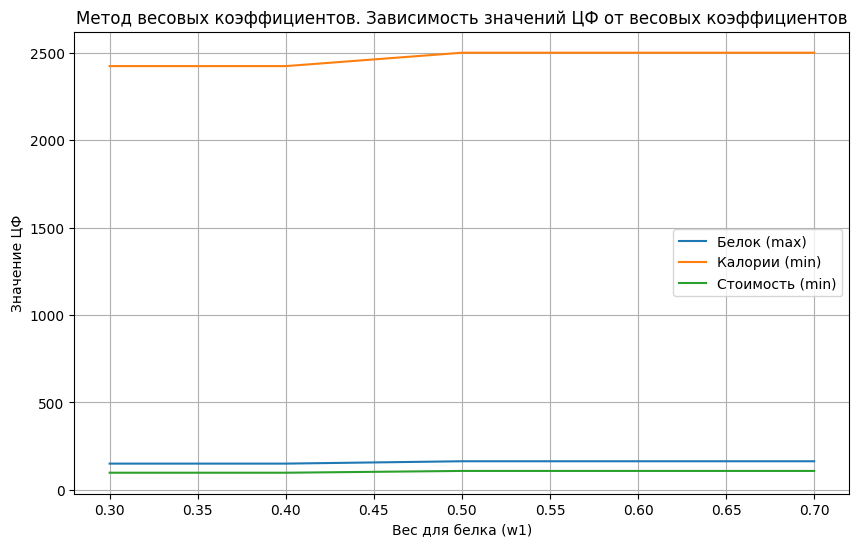

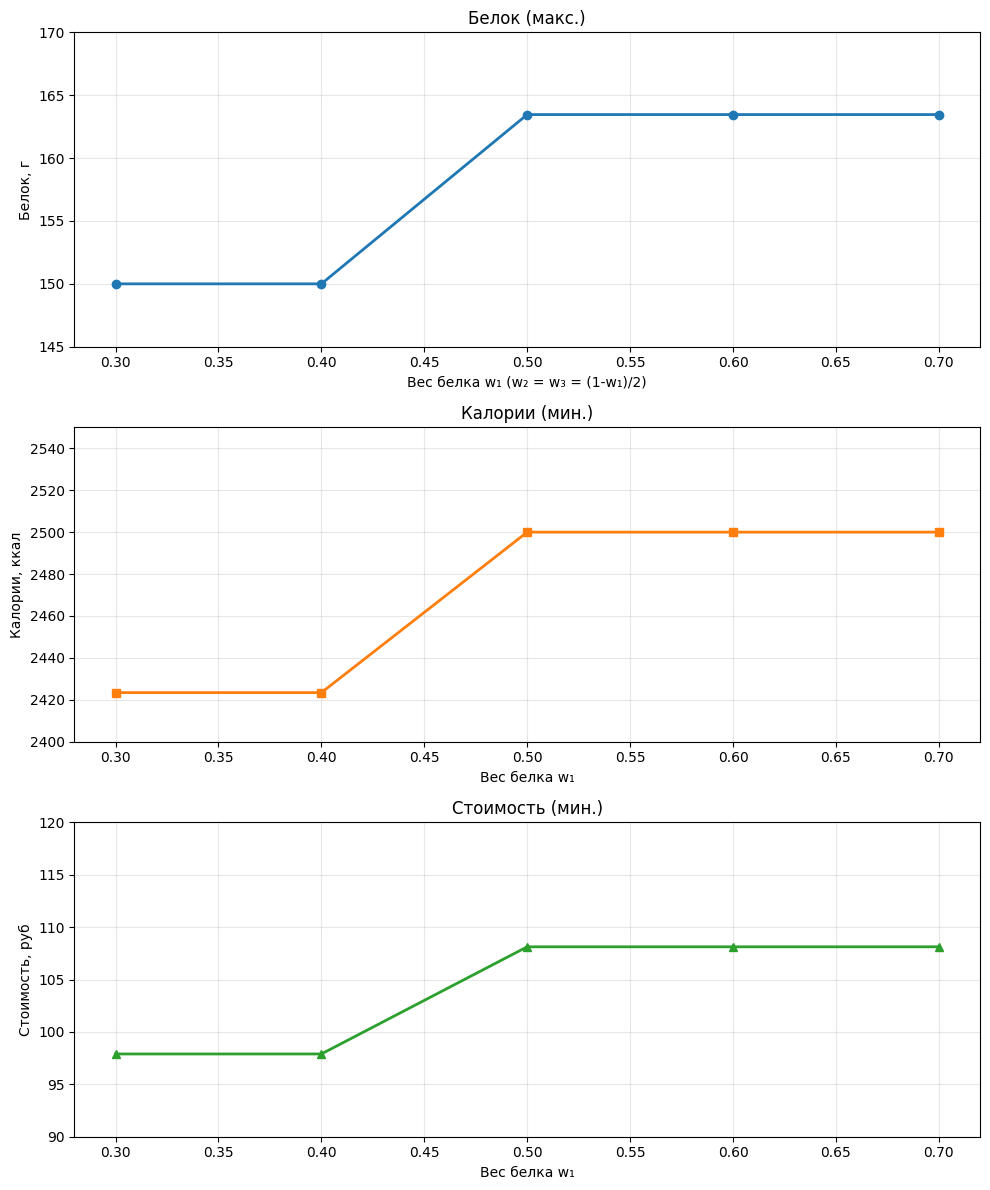

In [ ]:
# Коэффициенты
prot_coeffs = [0.25, 0.20, 0.13, 0.03, 0.01, 0.21]
cal_coeffs = [1.65, 2.08, 3.89, 0.34, 0.89, 5.79]
cost_coeffs = [0.20, 0.50, 0.05, 0.10, 0.07, 0.30]
carb_coeffs = [0, 0, 0.66, 0.07, 0.23, 0.22]
fat_coeffs = [0.03, 0.13, 0.07, 0, 0, 0.49]

# Предельные значения для нормализации
x = [pulp.LpVariable(f'x{i+1}', lowBound=0) for i in range(6)]

# 1. Максимальный белок при всех ограничениях
prob = pulp.LpProblem("Utopia_Protein", pulp.LpMaximize)
prob += pulp.lpSum(prot_coeffs[i] * x[i] for i in range(6))
for constr in [pulp.lpSum(x) <= 2000,
               pulp.lpSum(prot_coeffs[i] * x[i] for i in range(6)) >= 150,
               pulp.lpSum(cal_coeffs[i] * x[i] for i in range(6)) <= 2500,
               pulp.lpSum(carb_coeffs[i] * x[i] for i in range(6)) >= 300,
               pulp.lpSum(fat_coeffs[i] * x[i] for i in range(6)) >= 50]:
    prob += constr
prob.solve(pulp.PULP_CBC_CMD(msg=0))
max_prot = pulp.value(prob.objective)
print("Максимальный белок =", max_prot)

# 2. Минимальные калории при всех ограничениях
prob = pulp.LpProblem("Utopia_Calories", pulp.LpMinimize)
prob += pulp.lpSum(cal_coeffs[i] * x[i] for i in range(6))
for constr in [pulp.lpSum(x) <= 2000,
               pulp.lpSum(prot_coeffs[i] * x[i] for i in range(6)) >= 150,
               pulp.lpSum(cal_coeffs[i] * x[i] for i in range(6)) <= 2500,
               pulp.lpSum(carb_coeffs[i] * x[i] for i in range(6)) >= 300,
               pulp.lpSum(fat_coeffs[i] * x[i] for i in range(6)) >= 50]:
    prob += constr
prob.solve(pulp.PULP_CBC_CMD(msg=0))
min_cal = pulp.value(prob.objective)
print("Минимальные калории =", min_cal)

# 3. Минимальная стоимость при всех ограничениях
prob = pulp.LpProblem("Utopia_Cost", pulp.LpMinimize)
prob += pulp.lpSum(cost_coeffs[i] * x[i] for i in range(6))
for constr in [pulp.lpSum(x) <= 2000,
               pulp.lpSum(prot_coeffs[i] * x[i] for i in range(6)) >= 150,
               pulp.lpSum(cal_coeffs[i] * x[i] for i in range(6)) <= 2500,
               pulp.lpSum(carb_coeffs[i] * x[i] for i in range(6)) >= 300,
               pulp.lpSum(fat_coeffs[i] * x[i] for i in range(6)) >= 50]:
    prob += constr
prob.solve(pulp.PULP_CBC_CMD(msg=0))
min_cost = pulp.value(prob.objective)
print("Минимальная стоимость =", min_cost)

def solve_weights(w1, w2, w3):
    x = [pulp.LpVariable(f'x{i+1}', lowBound=0) for i in range(6)]
    prob = pulp.LpProblem("Weighted_Sum", pulp.LpMinimize)
    # Нормализованная сумма: -prot (для max), +cal, +cost
    prob += -w1 * (pulp.lpSum(prot_coeffs[i] * x[i] for i in range(6)) / max_prot) + \
            w2 * (pulp.lpSum(cal_coeffs[i] * x[i] for i in range(6)) / min_cal) + \
            w3 * (pulp.lpSum(cost_coeffs[i] * x[i] for i in range(6)) / min_cost)
    #Ограничения
    prob += pulp.lpSum(x) <= 2000
    prob += pulp.lpSum(prot_coeffs[i] * x[i] for i in range(6)) >= 150
    prob += pulp.lpSum(cal_coeffs[i] * x[i] for i in range(6)) <= 2500
    prob += pulp.lpSum(carb_coeffs[i] * x[i] for i in range(6)) >= 300
    prob += pulp.lpSum(fat_coeffs[i] * x[i] for i in range(6)) >= 50
    prob.solve(pulp.PULP_CBC_CMD(msg=0))
    if pulp.LpStatus[prob.status] != 'Optimal':
        return None, None, None

    # Итоговые значения целевых функций
    final_prot = sum(prot_coeffs[i] * pulp.value(x[i]) for i in range(6))
    final_cal = sum(cal_coeffs[i] * pulp.value(x[i]) for i in range(6))
    final_cost = sum(cost_coeffs[i] * pulp.value(x[i]) for i in range(6))
    return final_prot, final_cal, final_cost

# Тестирование
w1s = np.linspace(0.3, 0.7, 5)
results = []
for w1 in w1s:
    w2 = (1 - w1) / 2
    w3 = (1 - w1) / 2
    r = solve_weights(w1, w2, w3)
    if r[0] is not None:
        results.append(r)

prots = [r[0] for r in results]
cals = [r[1] for r in results]
costs = [r[2] for r in results]

# График
plt.figure(figsize=(10, 6))
plt.plot(w1s[:len(prots)], prots, label='Белок (max)')
plt.plot(w1s[:len(cals)], cals, label='Калории (min)')
plt.plot(w1s[:len(costs)], costs, label='Стоимость (min)')
plt.xlabel('Вес для белка (w1)')
plt.ylabel('Значение ЦФ')
plt.title('Метод весовых коэффициентов. Зависимость значений ЦФ от весовых коэффициентов')
plt.legend()
plt.grid(True)
plt.show()

fig, axs = plt.subplots(3, 1, figsize=(10, 12))

# 1. Белок
axs[0].plot(w1s, prots, 'o-', color='tab:blue', linewidth=2, markersize=6)
axs[0].set_title('Белок (макс.)')
axs[0].set_xlabel('Вес белка w₁ (w₂ = w₃ = (1-w₁)/2)')
axs[0].set_ylabel('Белок, г')
axs[0].grid(True, alpha=0.3)
axs[0].set_ylim(145, 170)

# 2. Калории
axs[1].plot(w1s, cals, 's-', color='tab:orange', linewidth=2, markersize=6)
axs[1].set_title('Калории (мин.)')
axs[1].set_xlabel('Вес белка w₁')
axs[1].set_ylabel('Калории, ккал')
axs[1].grid(True, alpha=0.3)
axs[1].set_ylim(2400, 2550)

# 3. Стоимость
axs[2].plot(w1s, costs, '^-', color='tab:green', linewidth=2, markersize=6)
axs[2].set_title('Стоимость (мин.)')
axs[2].set_xlabel('Вес белка w₁')
axs[2].set_ylabel('Стоимость, руб')
axs[2].grid(True, alpha=0.3)
axs[2].set_ylim(90, 120)

plt.tight_layout()
plt.show()

График демонстрирует, что в задаче существуют две резко различные Парето-оптимальные альтернативы:

1) При w₁ < 0,48–0,50:
дешёвый (96–98 руб) и наименее калорийный рацион (2420–2450 ккал), белок на нижней границе — 150 г.
2) При w₁ ≥ 0,50–0,52:
рацион с высоким содержанием белка (163–164 г), но с максимальной калорийностью (2500 ккал) и повышенной стоимостью (108–112 руб).